In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pyvis as ps
from os import listdir
import numpy as np
from math import ceil
import ast
from itertools import combinations
from time import time
import csv
import sys
from tqdm import tqdm

NAME = "MDPILESS"
WORKDIR = "/REF_GRA/"

In [2]:
# def pyvis_show(graph, phi=False, name="Default"):
#     net = Network()
#     net.from_nx(graph)
#     net.toggle_physics(phi)
#     net.show("/REF_GRA/{}_{}.html".format(name, time()), notebook=True)
    
# def print_graph_info(graph):
#     print("Graph     : ", f'{graph=}'.split('=')[0])
#     print("# vertices: ", graph.number_of_nodes())
#     print("# edges   : ", graph.number_of_edges())

def fix_keywords_lists(keyword_list):
    filter(None, keyword_list)
    temp = []
    
    for k in keyword_list:
        if ";" in k:
            k = k.strip(":").strip()
            temp.extend(k.split(";"))
            
        elif "‖" in k:
            temp.extend(k.split("‖"))
            
        elif "\xa0·" in k:
            temp.extend(k.split("\xa0·"))
            
        elif "·" in k:
            temp.extend(k.split("·"))
            
        elif "," in k:
            temp.extend(k.split(",")) 
        
        else:
            temp.append(k.strip())
        
    # Cleaning
    temp = [t.strip().lower() for t in temp]
    temp = [t for t in temp if len(t)>0]
    
    return temp

def write_dict_csv(dict, filepath="unnamed"):
    with open(f'{filepath}.csv', 'w') as f:
        w = csv.writer(f)
        
        for i in dict.items():
            w.writerow(i)

def neighbourhood_subgraph(graph, nodelist, n=10):
    # Find all nodes connected to the chosen nodes
    connected_nodes = set(nodelist[:n])
    for node in nodelist[:n]:
        connected_nodes.update(graph.neighbors(node))

    # Create the subgraph
    subG = graph.subgraph(connected_nodes)
    
    return subG

def graphs_are_equal(G1, G2):
    # Check if nodes are the same
    if set(G1.nodes) != set(G2.nodes):
        return False
    
    # Check if edges are the same
    if set(G1.edges) != set(G2.edges):
        return False
    
    # Check if node attributes are the same
    for node in G1.nodes:
        if G1.nodes[node] != G2.nodes[node]:
            return False
    
    # Check if edge attributes are the same
    for edge in G1.edges:
        if G1.edges[edge] != G2.edges[edge]:
            return False
    
    return True

## Loading data

In [3]:
DIR = "/REF_GRA/DATA/ED4RE_2603.pickle"

df = pd.read_pickle(DIR)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 171880 entries, 0 to 10
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Title                     171880 non-null  object
 1   Authors_and_Affiliations  171880 non-null  object
 2   Affiliations              171880 non-null  object
 3   DOI                       171880 non-null  object
 4   Authors                   171880 non-null  object
 5   Journal                   171880 non-null  object
 6   Date                      171880 non-null  object
 7   Subjects                  171880 non-null  object
 8   Abstract                  171880 non-null  object
 9   References                171880 non-null  object
 10  Content                   171880 non-null  object
 11  Keywords                  171880 non-null  object
 12  Style                     171880 non-null  object
dtypes: object(13)
memory usage: 18.4+ MB
None


## Filtering

### MDPI remove

In [4]:
MDPI_JOURNALS = ["Air", "Atmosphere", "Climate", "Earth", 
                 "Ecologies", "Energies", "Environments", 
                 "Forests", "Fuels", "Hydrology", 
                 "Meteorology", "Oceans", "Recycling", "Water"]
if NAME == "MDPILESS":
    df = df[~df["Journal"].isin(MDPI_JOURNALS)]

### Empty

In [5]:
nonempty_df = df[~df["Keywords"].str.contains("no_keywords", na=False)]

print(nonempty_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 80526 entries, 0 to 10
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Title                     80526 non-null  object
 1   Authors_and_Affiliations  80526 non-null  object
 2   Affiliations              80526 non-null  object
 3   DOI                       80526 non-null  object
 4   Authors                   80526 non-null  object
 5   Journal                   80526 non-null  object
 6   Date                      80526 non-null  object
 7   Subjects                  80526 non-null  object
 8   Abstract                  80526 non-null  object
 9   References                80526 non-null  object
 10  Content                   80526 non-null  object
 11  Keywords                  80526 non-null  object
 12  Style                     80526 non-null  object
dtypes: object(13)
memory usage: 8.6+ MB
None


### Percentile, median, mean

/tmp/ipykernel_145975/1101534465.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nonempty_df['Keywords_length'] = nonempty_df['Keywords'].apply(len)


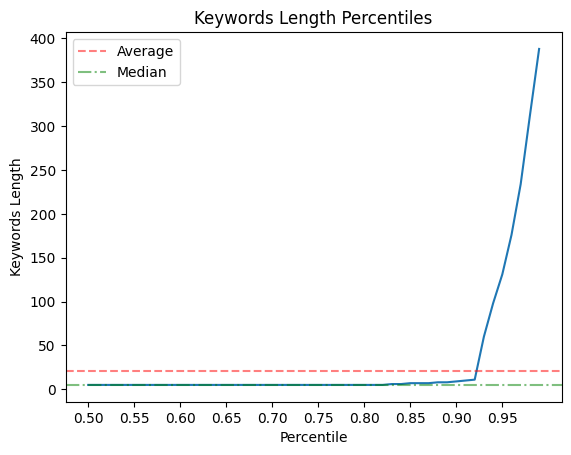

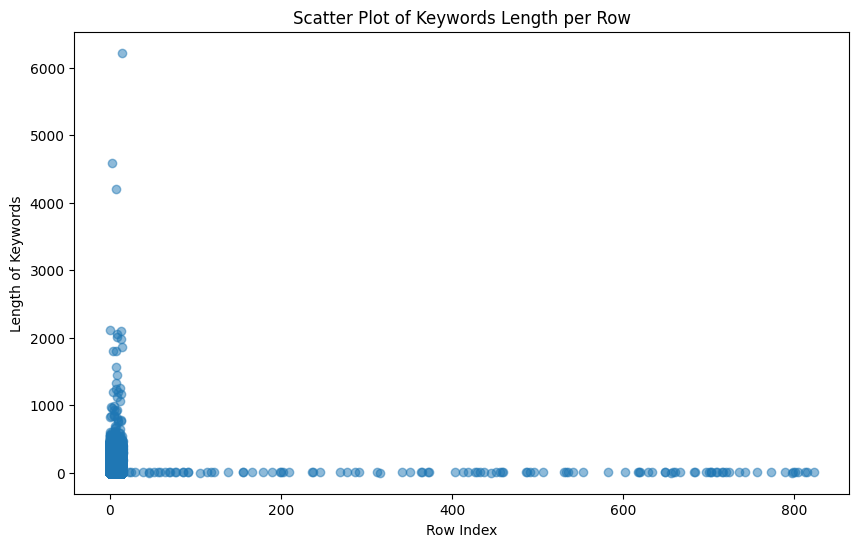

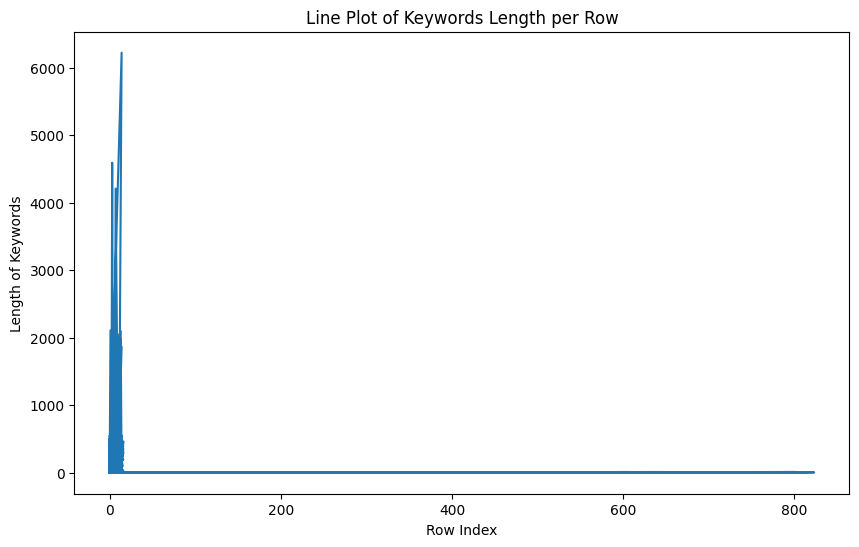

In [6]:
# Calculate the length of each entry in the 'Keywords' column
nonempty_df['Keywords_length'] = nonempty_df['Keywords'].apply(len)


percentiles = [nonempty_df['Keywords_length'].quantile(a/100) for a in range(50, 100)]
average_length = nonempty_df['Keywords_length'].mean()
median_length = nonempty_df['Keywords_length'].median()

plt.plot([a/100 for a in range(50,100)], percentiles)
plt.xticks([a/100 for a in range(50,100,5)])
plt.title('Keywords Length Percentiles')
plt.xlabel('Percentile')
plt.ylabel('Keywords Length')
plt.axhline(average_length, color='r', linestyle='--', label='Average', alpha=0.5)
plt.axhline(median_length, color='g', linestyle='-.', label='Median', alpha=0.5)
plt.legend()
plt.show()

# Create a scatter plot of the keyword lengths
plt.figure(figsize=(10, 6))
plt.scatter(nonempty_df.index, nonempty_df['Keywords_length'], alpha=0.5)
plt.title('Scatter Plot of Keywords Length per Row')
plt.xlabel('Row Index')
plt.ylabel('Length of Keywords')
plt.show()

# Create a line plot of the keyword lengths
plt.figure(figsize=(10, 6))
plt.plot(nonempty_df.index, nonempty_df['Keywords_length'])
plt.title('Line Plot of Keywords Length per Row')
plt.xlabel('Row Index')
plt.ylabel('Length of Keywords')
plt.show()

### Filter by mean

In [7]:
print("Mean length of keywords: ", average_length)

mean_empty_df = nonempty_df[nonempty_df["Keywords_length"] <= ceil(average_length)]


Mean length of keywords:  20.88176489581005


In [8]:
print(mean_empty_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 74774 entries, 0 to 10
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Title                     74774 non-null  object
 1   Authors_and_Affiliations  74774 non-null  object
 2   Affiliations              74774 non-null  object
 3   DOI                       74774 non-null  object
 4   Authors                   74774 non-null  object
 5   Journal                   74774 non-null  object
 6   Date                      74774 non-null  object
 7   Subjects                  74774 non-null  object
 8   Abstract                  74774 non-null  object
 9   References                74774 non-null  object
 10  Content                   74774 non-null  object
 11  Keywords                  74774 non-null  object
 12  Style                     74774 non-null  object
 13  Keywords_length           74774 non-null  int64 
dtypes: int64(1), object(13)
memory

## Graph

In [9]:
test = mean_empty_df["Keywords"].sample(1).tolist()[0]
print(test)
print(test[0])

['paleomagnetism', 'paleointensity', 'rock magnetism', 'magnetic domain state']
paleomagnetism


In [10]:
N = len(mean_empty_df)
G = nx.Graph()
for keywords in mean_empty_df["Keywords"].sample(N):
    filter(None, keywords)
    temp = []
    
    for k in keywords:
        if ";" in k:
            k = k.strip(":").strip()
            temp.extend(k.split(";"))
            
        elif "‖" in k:
            temp.extend(k.split("‖"))
            
        elif "\xa0·" in k:
            temp.extend(k.split("\xa0·"))
            
        elif "·" in k:
            temp.extend(k.split("·"))
            
        elif "," in k:
            temp.extend(k.split(",")) 
        
        else:
            temp.append(k.strip())
        
    # Cleaning
    temp = [t.strip().lower() for t in temp]
    temp = [t for t in temp if len(t)>0]
    
    # print(temp)
    
    for comb in list(combinations(temp, 2)):
        if G.has_edge(comb[0], comb[1]):
            G[comb[0]][comb[1]]['width'] += 1
        elif G.has_edge(comb[1], comb[0]):
            G[comb[1]][comb[0]]['width'] += 1
        else:
            G.add_edge(comb[0], comb[1], width=1)


# Assuming G is your graph
# degree_centrality = nx.degree_centrality(G)
# # Sort nodes by degree centrality and get top 100

# top_100_nodes = [n for (n,c) in degree_centrality if c in np.argsort(c)[-100:]]
# # Print or use top nodes
# print("Top 1000 nodes by degree centrality:")
# for node in top_nodes:
#     print(node, " ", len(node))

# net = ps.network.Network(notebook=True, height='750px', width='100%', cdn_resources='remote')
# net.from_nx(G)
# net.show(f"/REF_GRA/keywords_graph_{N}.html")
nx.write_edgelist(G, path=f"/REF_GRA/GRAPHS/keyword_graph_{NAME}.edgelist", delimiter=":")
nx.write_graphml(G, path=f"/REF_GRA/GRAPHS/keyword_graph_{NAME}.graphml")

## Statistics

In [11]:
print(G)

Graph with 127828 nodes and 684733 edges


### Occurance

In [12]:
mean_empty_df["Keywords"] = mean_empty_df["Keywords"].apply(fix_keywords_lists)

exploded_mean_empty_df = mean_empty_df["Keywords"].explode()

keyword_counts = exploded_mean_empty_df.value_counts()

/tmp/ipykernel_145975/730377241.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_empty_df["Keywords"] = mean_empty_df["Keywords"].apply(fix_keywords_lists)


In [13]:
write_dict_csv(keyword_counts.to_dict(), WORKDIR + "/RESULTS/" +"counts_"+NAME+"_"+str(round(time())))

### Degree

In [14]:
degree_centrality = nx.degree_centrality(G)
sorted_degree_centrality = sorted(degree_centrality, key=degree_centrality.get, reverse=True)

print(sorted_degree_centrality[:10])

['climate change', 'evolution', 'precipitation', 'usa', 'temperature', 'biodiversity', 'drought', 'conservation', 'climate', 'global warming']


In [15]:
write_dict_csv(degree_centrality, WORKDIR + "/RESULTS/" +"degree_"+NAME+"_"+str(round(time())))

### Eigenvector 

In [16]:
eigenvector_centrality = nx.eigenvector_centrality(G)
sorted_eigenvector_centrality = sorted(eigenvector_centrality, key=eigenvector_centrality.get, reverse=True)

print(sorted_eigenvector_centrality[:10])

['climate change', 'temperature', 'precipitation', 'drought', 'biodiversity', 'usa', 'climate', 'global warming', 'global change', 'conservation']


In [17]:
write_dict_csv(eigenvector_centrality, WORKDIR + "/RESULTS/" +"eigen_"+NAME+"_"+str(round(time())))

In [18]:
print("DEG \t\t EIG \t\t #")
for i in range(0, 100):
    print(f"{sorted_degree_centrality[i]} \t\t {sorted_eigenvector_centrality[i]} \t\t {keyword_counts.keys()[i]}")

DEG 		 EIG 		 #
climate change 		 climate change 		 climate change
evolution 		 temperature 		 evolution
precipitation 		 precipitation 		 precipitation
usa 		 drought 		 inflammation
temperature 		 biodiversity 		 cancer
biodiversity 		 usa 		 temperature
drought 		 climate 		 apoptosis
conservation 		 global warming 		 innate immunity
climate 		 global change 		 transcription
global warming 		 conservation 		 enso
inflammation 		 disturbance 		 biodiversity
cancer 		 nitrogen 		 drought
remote sensing 		 remote sensing 		 mitochondria
disturbance 		 carbon 		 signal transduction
global change 		 phenology 		 x-ray crystallography
enso 		 agriculture 		 climate
photosynthesis 		 soil 		 development
nitrogen 		 restoration 		 aging
apoptosis 		 land use 		 protein folding
transcription 		 invasive species 		 hippocampus
development 		 carbon sequestration 		 global warming
x-ray crystallography 		 evolution 		 photosynthesis
mitochondria 		 warming 		 climate variability
innate immunit

#### Subgraphs

In [19]:
for i in tqdm(range(20)):
    
    # Degree centrality
    degree_10 = neighbourhood_subgraph(G, sorted_degree_centrality, i)
    print("Degree: ", degree_10)

    # Eigenvector centrality
    eigen_10 = neighbourhood_subgraph(G, sorted_eigenvector_centrality, i)
    print("Eigen: ", degree_10)

    # Counts
    count_10 = neighbourhood_subgraph(G, keyword_counts.keys(), i)
    print("Counts: ", count_10)
    
    nx.write_graphml(degree_10, path=f"/REF_GRA/GRAPHS/SUBGRAPHS/degree_{i}_{NAME}.graphml")
    
    if graphs_are_equal(degree_10, eigen_10):
        pass
    else:
        nx.write_graphml(eigen_10, path=f"/REF_GRA/GRAPHS/SUBGRAPHS/eigen_{i}_{NAME}.graphml")
        
    if graphs_are_equal(count_10, eigen_10) or graphs_are_equal(count_10, degree_10):
        pass
    else:
        nx.write_graphml(eigen_10, path=f"/REF_GRA/GRAPHS/SUBGRAPHS/count_{i}_{NAME}.graphml")
        
    
    
    

  0%|          | 0/20 [00:00<?, ?it/s]

Degree:  Graph with 0 nodes and 0 edges
Eigen:  Graph with 0 nodes and 0 edges
Counts:  Graph with 0 nodes and 0 edges
Degree:  Graph with 7738 nodes and 96776 edges
Eigen:  Graph with 7738 nodes and 96776 edges
Counts:  Graph with 7738 nodes and 96776 edges


 10%|█         | 2/20 [00:04<00:41,  2.33s/it]

Degree:  Graph with 9336 nodes and 113996 edges
Eigen:  Graph with 9336 nodes and 113996 edges
Counts:  Graph with 9336 nodes and 113996 edges


 15%|█▌        | 3/20 [00:10<01:02,  3.67s/it]

...

 90%|█████████ | 18/20 [02:19<00:19,  9.62s/it]

Degree:  Graph with 19136 nodes and 216398 edges
Eigen:  Graph with 19136 nodes and 216398 edges
Counts:  Graph with 19535 nodes and 215011 edges


 95%|█████████▌| 19/20 [02:29<00:09,  9.66s/it]

Degree:  Graph with 19770 nodes and 222280 edges
Eigen:  Graph with 19770 nodes and 222280 edges
Counts:  Graph with 20083 nodes and 218416 edges


100%|██████████| 20/20 [02:39<00:00,  7.97s/it]
